In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    "Heart_Disease_Mortality_Data_Among_US_Adults__35___by_State_Territory_and_County___2018-2020.csv"
)


In [3]:
# Check shape and column names
print(df.shape)
print(df.columns)


(59094, 20)
Index(['Year', 'LocationAbbr', 'LocationDesc', 'GeographicLevel', 'DataSource',
       'Class', 'Topic', 'Data_Value', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'StratificationCategory1', 'Stratification1', 'StratificationCategory2',
       'Stratification2', 'TopicID', 'LocationID', 'Y_lat', 'X_lon'],
      dtype='object')


In [4]:
# Filter only county-level records
df = df[df["GeographicLevel"] == "County"]


In [5]:
# Drop rows with missing mortality rate
df = df[df["Data_Value"].notna()]


In [6]:
# Calculate median mortality rate
median_mortality = df["Data_Value"].median()

# Create binary target column
df["target"] = (df["Data_Value"] > median_mortality).astype(int)


In [7]:
# Remove continuous target column
df = df.drop(columns=["Data_Value"])


In [8]:
# Columns to drop (metadata / identifiers)
drop_cols = [
    "Data_Value_Unit",
    "Data_Value_Type",
    "Low_Confidence_Limit",
    "High_Confidence_Limit",
    "Topic",
    "TopicID",
    "DataSource",
    "LocationID"
]

df = df.drop(columns=drop_cols, errors="ignore")


In [9]:
# Rename columns for cleaner coding
df = df.rename(columns={
    "LocationAbbr": "state_abbr",
    "LocationDesc": "state_name",
    "GeographicLevel": "geo_level",
    "County": "county",
    "Race": "race",
    "Sex": "sex",
    "AgeGroup": "age_group"
})


In [10]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()


Duplicate rows: 0


In [11]:
# Final overview
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 32227 entries, 0 to 59069
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        32227 non-null  int64  
 1   state_abbr                  32227 non-null  object 
 2   state_name                  32227 non-null  object 
 3   geo_level                   32227 non-null  object 
 4   Class                       32227 non-null  object 
 5   Data_Value_Footnote_Symbol  0 non-null      object 
 6   Data_Value_Footnote         0 non-null      object 
 7   StratificationCategory1     32227 non-null  object 
 8   Stratification1             32227 non-null  object 
 9   StratificationCategory2     32227 non-null  object 
 10  Stratification2             32227 non-null  object 
 11  Y_lat                       32227 non-null  float64
 12  X_lon                       32227 non-null  float64
 13  target                      32227 no

,Year,state_abbr,state_name,geo_level,Class,Data_Value_Footnote_Symbol,Data_Value_Footnote,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,Y_lat,X_lon,target
0,2019,AK,Aleutians East,County,Cardiovascular Diseases,NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,55.442393,-161.959930,0
1,2019,AK,Aleutians West,County,Cardiovascular Diseases,NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,53.648343,-166.917533,0
2,2019,AK,Anchorage,County,Cardiovascular Diseases,NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,61.159145,-149.104559,0
3,2019,AK,Bethel,County,Cardiovascular Diseases,NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,60.923648,-159.753262,1
5,2019,AK,Denali,County,Cardiovascular Diseases,NaN,NaN,Sex,Overall,Race/Ethnicity,Overall,63.678820,-149.960801,0


In [12]:
# Check class distribution
df["target"].value_counts()


,count
target,
0,16116
1,16111


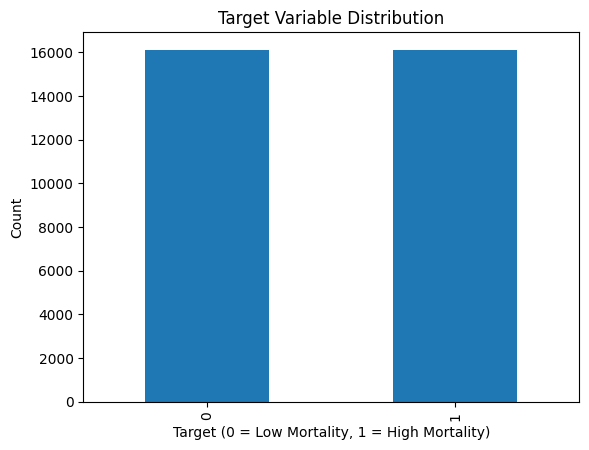

In [13]:
# Plot target distribution
import matplotlib.pyplot as plt

plt.figure()
df["target"].value_counts().plot(kind="bar")
plt.xlabel("Target (0 = Low Mortality, 1 = High Mortality)")
plt.ylabel("Count")
plt.title("Target Variable Distribution")
plt.show()


In [14]:
# Filter rows where stratification is Sex
df_sex = df[df["StratificationCategory1"] == "Sex"]

# Check mortality risk by sex
pd.crosstab(df_sex["Stratification1"], df_sex["target"], normalize="index")



target,0,1
Stratification1,,
Female,0.772259,0.227741
Male,0.236305,0.763695
Overall,0.504749,0.495251


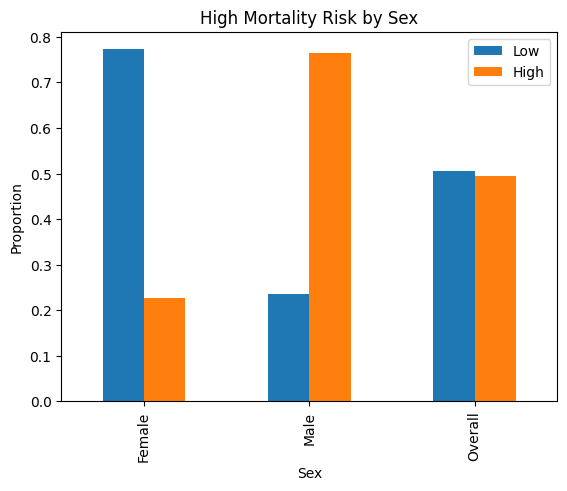

In [15]:
# Plot
import matplotlib.pyplot as plt

pd.crosstab(df_sex["Stratification1"], df_sex["target"], normalize="index").plot(kind="bar")
plt.xlabel("Sex")
plt.ylabel("Proportion")
plt.title("High Mortality Risk by Sex")
plt.legend(["Low", "High"])
plt.show()


In [16]:
# Check the exact category names available
print(df["StratificationCategory1"].value_counts())




StratificationCategory1
Sex    32227
Name: count, dtype: int64


In [17]:
print(df["StratificationCategory1"].unique())


['Sex']


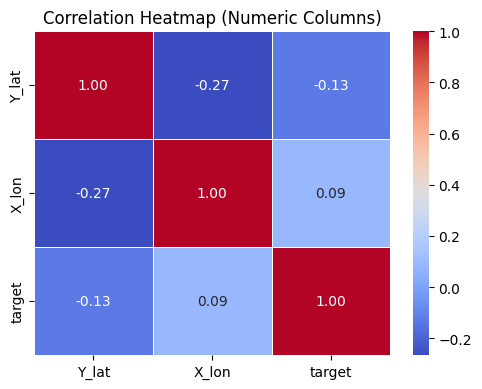

In [18]:
# -------------------------------
# Heatmap using numerical columns (excluding Year)
# -------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Drop Year because it is a time index, not a true feature
numeric_df = numeric_df.drop(columns=["Year"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(5,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()


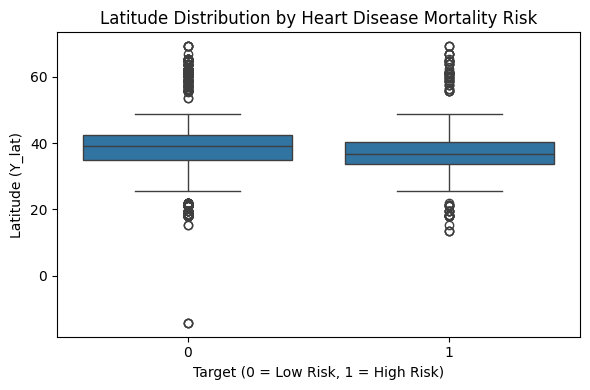

In [19]:
# -------------------------------
# Box plot: Latitude vs Mortality Risk
# -------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# Box plot comparing latitude distribution by target class
sns.boxplot(
    x="target",
    y="Y_lat",
    data=df
)

plt.xlabel("Target (0 = Low Risk, 1 = High Risk)")
plt.ylabel("Latitude (Y_lat)")
plt.title("Latitude Distribution by Heart Disease Mortality Risk")
plt.tight_layout()
plt.show()


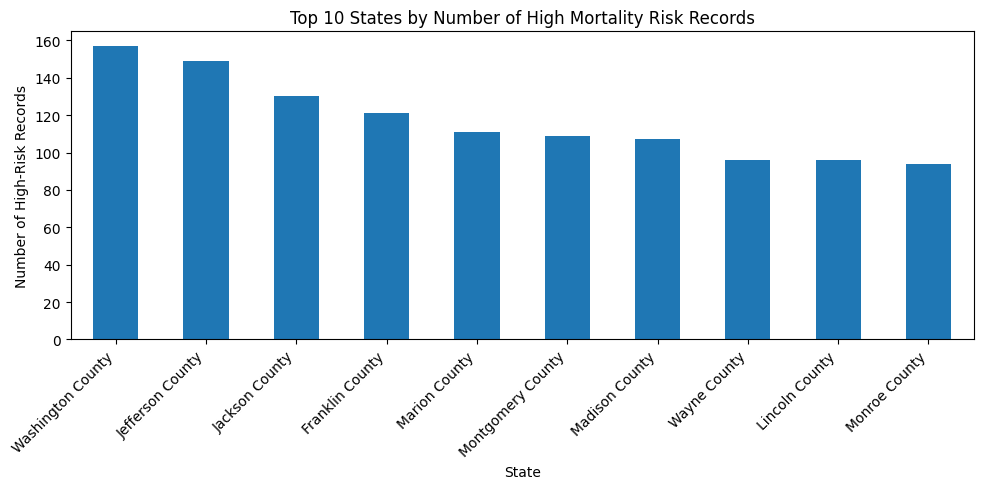

In [20]:
# -------------------------------
# Plot 1: Count of high-risk records by state
# -------------------------------

import matplotlib.pyplot as plt

# Count high-risk records per state
state_high_risk_counts = (
    df[df["target"] == 1]
    .groupby("state_name")
    .size()
    .sort_values(ascending=False)
)

# Plot top 10 states
plt.figure(figsize=(10,5))
state_high_risk_counts.head(10).plot(kind="bar")

plt.xlabel("State")
plt.ylabel("Number of High-Risk Records")
plt.title("Top 10 States by Number of High Mortality Risk Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Separate features and target
X = df.drop(columns=["target"])
y = df["target"]


In [22]:
# Categorical columns (object type)
categorical_cols = X.select_dtypes(include="object").columns

# Numerical columns (exclude target)
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
print("Categorical columns:", categorical_cols.tolist())
print("Numerical columns:", numerical_cols.tolist())


Categorical columns: ['state_abbr', 'state_name', 'geo_level', 'Class', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote', 'StratificationCategory1', 'Stratification1', 'StratificationCategory2', 'Stratification2']
Numerical columns: ['Year', 'Y_lat', 'X_lon']


In [23]:
# Dictionary to store encoders
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves class balance
)


In [25]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [26]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (25781, 13)
Test set shape: (6446, 13)


In [27]:
# -------------------------------
# XGBoost Model
# -------------------------------

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 0.8872168786844554

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89      3224
           1       0.88      0.89      0.89      3222

    accuracy                           0.89      6446
   macro avg       0.89      0.89      0.89      6446
weighted avg       0.89      0.89      0.89      6446



In [28]:
# -------------------------------
# Random Forest Model
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.899627676078188

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      3224
           1       0.90      0.89      0.90      3222

    accuracy                           0.90      6446
   macro avg       0.90      0.90      0.90      6446
weighted avg       0.90      0.90      0.90      6446



In [29]:
# -------------------------------
# KNN Model
# -------------------------------

from sklearn.neighbors import KNeighborsClassifier

# Initialize model
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"   # improves performance
)

# Train model
knn_model.fit(X_train, y_train)

# Predictions
knn_pred = knn_model.predict(X_test)

# Evaluation
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("\nKNN Classification Report:\n")
print(classification_report(y_test, knn_pred))


KNN Accuracy: 0.6552901023890785

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.64      0.65      3224
           1       0.65      0.68      0.66      3222

    accuracy                           0.66      6446
   macro avg       0.66      0.66      0.66      6446
weighted avg       0.66      0.66      0.66      6446



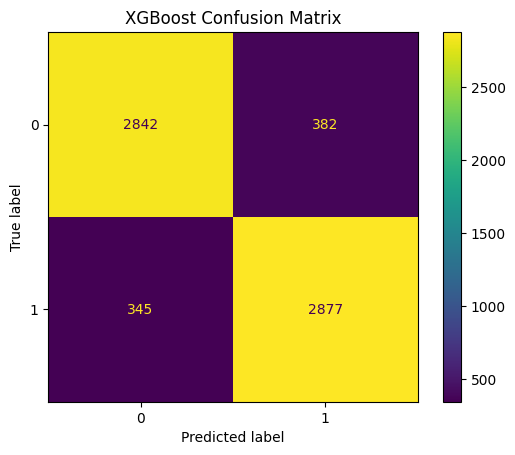

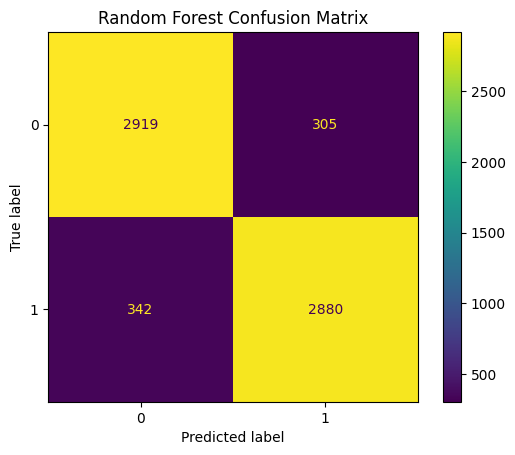

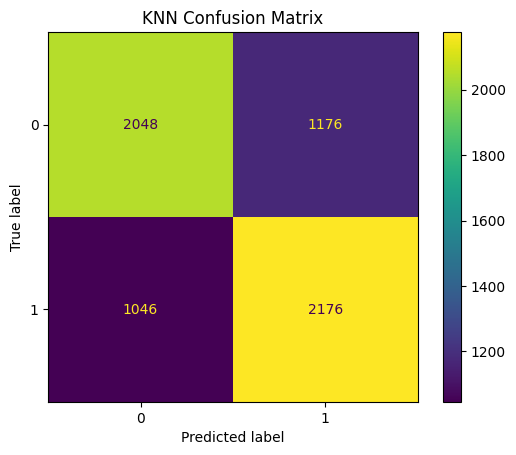

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, xgb_pred)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()


cm_rf = confusion_matrix(y_test, rf_pred)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

cm_knn = confusion_matrix(y_test, knn_pred)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title("KNN Confusion Matrix")
plt.show()


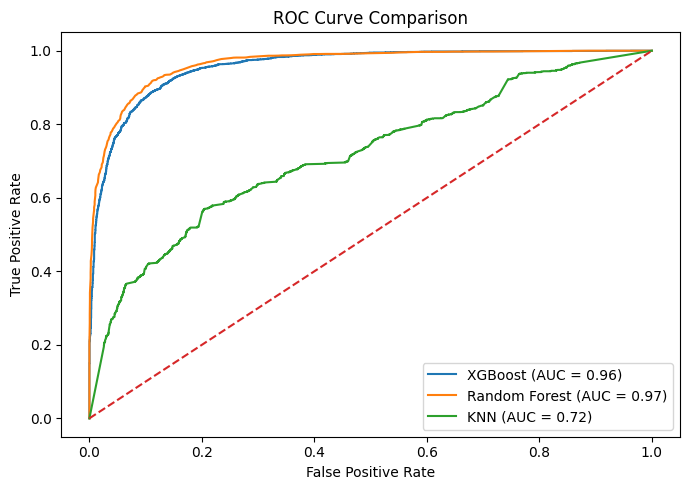

In [31]:
from sklearn.metrics import roc_curve, auc
# Get prediction probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
knn_probs = knn_model.predict_proba(X_test)[:, 1]

# Compute ROC curves
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)

# Compute AUC scores
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_rf = auc(fpr_rf, tpr_rf)
auc_knn = auc(fpr_knn, tpr_knn)

# Plot ROC curves
plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


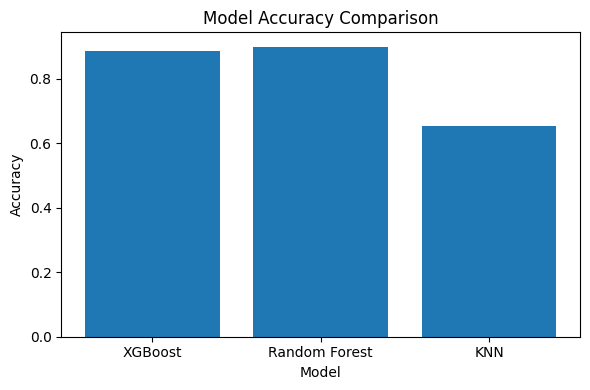

In [32]:
from sklearn.metrics import accuracy_score

# Accuracy values
accuracy_scores = {
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "KNN": accuracy_score(y_test, knn_pred)
}

# Plot accuracy comparison
plt.figure(figsize=(6,4))
plt.bar(accuracy_scores.keys(), accuracy_scores.values())

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()


In [35]:
# Import required tools
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report

# Stratified cross-validation (keeps class balance in folds)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# -------------------------------
# XGBoost Hyperparameter Tuning
# -------------------------------

from xgboost import XGBClassifier

# Initialize base XGBoost model
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Define parameter search space (kept small for speed)
xgb_param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# RandomizedSearchCV for faster tuning
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=10,              # small number of trials (FAST)
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit tuning on training data only
xgb_search.fit(X_train, y_train)

# Get best tuned model
best_xgb = xgb_search.best_estimator_

print("Best XGBoost Parameters:", xgb_search.best_params_)

# Evaluate on test data
xgb_probs = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred = best_xgb.predict(X_test)

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_probs))
print(classification_report(y_test, xgb_pred))



Best XGBoost Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
XGBoost ROC-AUC: 0.9616357879220557
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      3224
           1       0.89      0.90      0.90      3222

    accuracy                           0.89      6446
   macro avg       0.89      0.89      0.89      6446
weighted avg       0.89      0.89      0.89      6446



In [38]:
# -------------------------------
# Random Forest Hyperparameter Tuning
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

# Initialize base Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Parameter search space (reduced for speed)
rf_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

# RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=10,              # FAST
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
rf_search.fit(X_train, y_train)

# Best tuned model
best_rf = rf_search.best_estimator_

print("Best Random Forest Parameters:", rf_search.best_params_)

# Evaluate on test data
rf_probs = best_rf.predict_proba(X_test)[:, 1]
rf_pred = best_rf.predict(X_test)

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_probs))
print(classification_report(y_test, rf_pred))


Best Random Forest Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Random Forest ROC-AUC: 0.9655757736436688
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      3224
           1       0.90      0.89      0.90      3222

    accuracy                           0.90      6446
   macro avg       0.90      0.90      0.90      6446
weighted avg       0.90      0.90      0.90      6446



In [37]:
# -------------------------------
# KNN Hyperparameter Tuning
# -------------------------------

from sklearn.neighbors import KNeighborsClassifier

# Initialize base KNN model
knn_model = KNeighborsClassifier()

# Parameter search space
knn_param_dist = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# RandomizedSearchCV
knn_search = RandomizedSearchCV(
    estimator=knn_model,
    param_distributions=knn_param_dist,
    n_iter=10,              # FAST
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
knn_search.fit(X_train, y_train)

# Best tuned model
best_knn = knn_search.best_estimator_

print("Best KNN Parameters:", knn_search.best_params_)

# Evaluate on test data
knn_probs = best_knn.predict_proba(X_test)[:, 1]
knn_pred = best_knn.predict(X_test)

print("KNN ROC-AUC:", roc_auc_score(y_test, knn_probs))
print(classification_report(y_test, knn_pred))


Best KNN Parameters: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
KNN ROC-AUC: 0.7594930286969392
              precision    recall  f1-score   support

           0       0.69      0.68      0.69      3224
           1       0.69      0.70      0.69      3222

    accuracy                           0.69      6446
   macro avg       0.69      0.69      0.69      6446
weighted avg       0.69      0.69      0.69      6446

